In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("/content/accident_data.csv")

In [14]:
df.shape

(270787, 68)

In [15]:
df.head()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Local_Authority_(District),1st_Road_Class,...,Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type,Vehicle_IMD_Decile,year,Month,Day_of_month,Hour,Accident_Severity
0,534140.0,168370.0,-0.073120,51.398512,1,2,1,3,20,3,...,1,-1,8,2,8,2018,9,25,12,high
1,534140.0,168370.0,-0.073120,51.398512,1,2,1,3,20,3,...,1,16,-1,-1,-1,2018,9,25,12,high
2,535780.0,185300.0,-0.043058,51.550261,1,1,1,6,4,5,...,-1,-1,-1,-1,-1,2018,9,7,11,high
3,534120.0,192440.0,-0.064263,51.614820,1,1,1,5,32,6,...,2,1,1,1,1,2018,9,27,8,high
4,529080.0,162590.0,-0.147913,51.347739,1,2,2,4,21,3,...,1,8,10,1,10,2018,9,26,19,high


In [16]:
X = df.drop("Accident_Severity",axis =1 )
y = df['Accident_Severity']

In [17]:
y.unique()

array(['high', 'medium', 'low'], dtype=object)

In [18]:
y = y.replace({'low':0,'medium':1,'high':2})

/tmp/ipykernel_2386/1684636833.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'low':0,'medium':1,'high':2})


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [21]:
import tensorflow as tf

In [26]:
model =tf.keras.models.Sequential([
    tf.keras.layers.Dense(1024,activation='relu',input_shape=X_train.shape[1:]),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(optimizer='adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

In [28]:
history = model.fit(
    X_train,y_train,
    epochs = 10,
    batch_size = 128,
    validation_split=0.1,
)

Epoch 1/10
1524/1524 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6458 - loss: 1528.7363 - val_accuracy: 0.2297 - val_loss: 77.8955
Epoch 2/10
1524/1524 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6505 - loss: 30.6826 - val_accuracy: 0.3271 - val_loss: 1.4927
Epoch 3/10
1524/1524 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7238 - loss: 1.6165 - val_accuracy: 0.7762 - val_loss: 0.6490
Epoch 4/10
1524/1524 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7687 - loss: 10.8528 - val_accuracy: 0.7765 - val_loss: 0.6116
Epoch 5/10
1524/1524 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7784 - loss: 0.6059 - val_accuracy: 0.7765 - val_loss: 0.5983
Epoch 6/10
1524/1524 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7783 - loss: 0.5957 - val_accuracy: 0.7765 - val_loss: 0.5976
Epoch 7/10
1524/1524 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7799 - loss: 0.5947 - val_accuracy: 0.7765 - val_loss: 0.5975
Epoch 8/10
1524/1524 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7781 - loss: 0.5

In [29]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(loss)+1)

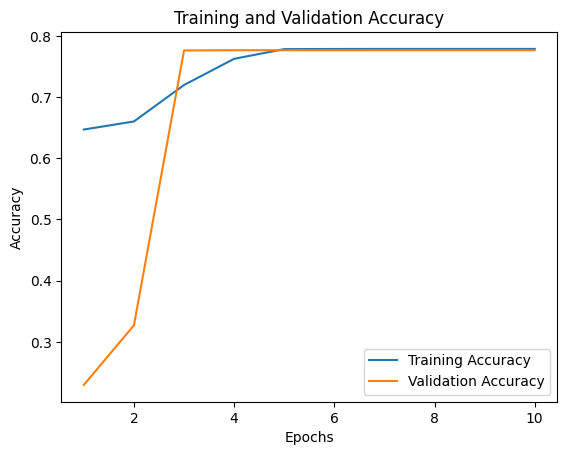

In [30]:
plt.plot(epochs,accuracy,label='Training Accuracy')
plt.plot(epochs,val_accuracy,label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

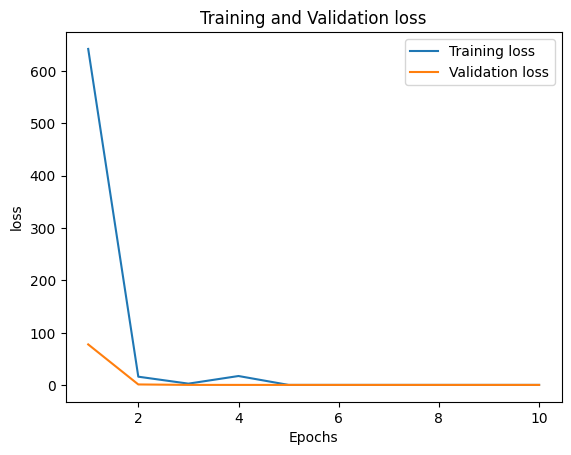

In [31]:
plt.plot(epochs,loss,label='Training loss')
plt.plot(epochs,val_loss,label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.show()

In [32]:
loss ,acc = model.evaluate(X_test,y_test)

1693/1693 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7776 - loss: 0.5973


In [33]:
y_pred = model.predict(X_test)

1693/1693 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [38]:
y_pred = y_pred.argmax(axis =1)

In [39]:
from sklearn.metrics import confusion_matrix,classification_report

In [40]:
cm = confusion_matrix(y_test,y_pred)

<Axes: >

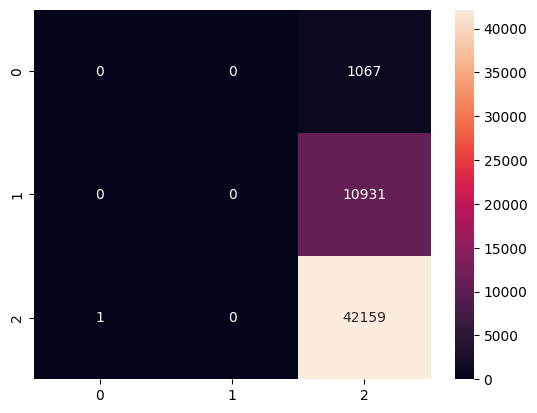

In [41]:
sns.heatmap(cm,annot=True,fmt='d')

In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1067
           1       0.00      0.00      0.00     10931
           2       0.78      1.00      0.88     42160

    accuracy                           0.78     54158
   macro avg       0.26      0.33      0.29     54158
weighted avg       0.61      0.78      0.68     54158



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
